# Tutorial

In [1]:
from risma import AquariusWebPortal

## Establish connection to the website

To demonstrate I'll create three connections to different examples of Aquarius Web Portal implementations, all configured in different ways, using different versions of the software.

In [2]:
aafc = AquariusWebPortal(server="agrifood.aquaticinformatics.net", auto_accept_disclaimer=True)

## Getting a list of parameters

For some portals you can get back a list of parameters:

In [3]:
params = aafc.fetch_params()
params

,param_id,param_name,param_desc
0,18,Air Temp,Air Temperature
1,21,Atmos Pres,Atmospheric Pressure
2,116,Dew Point,Dew Point Temperature
3,144,Discharge,Discharge
4,1,Stage,Height of Gauge (River Stage)
5,95,Precip Total,Precipitation Total
6,121,ETo,Reference Evapotranspiration
7,24,Rel Humidity,Relative Humidity
8,98,Soil Moisture,"Soil Moisture, by volume"
9,124,Soil temperature,Soil temperature


## Getting a list of locations (sites)

For either type of portal you can fetch a list of locations:

In [4]:
stations = aafc.fetch_locations()
stations

,wp_loc_id,lon,lat,loc_name,loc_id,loc_type,loc_folder,classification,bgcolor,seq
0,1543,-75.719780,45.385480,RISMA Ontario Central Experimental Farm,RISMA_CEF1,RISMA Station,All Locations.Public.RISMA,-,#FFFFFF,0
1,1523,-98.019240,49.562340,RISMA Manitoba Station 1,RISMA_MB1,RISMA Station,All Locations.Public.RISMA,-,#FFFFFF,0
2,1531,-97.348290,49.975360,RISMA Manitoba Station 10,RISMA_MB10,RISMA Station,All Locations.Public.RISMA,-,#FFFFFF,0
3,1533,-97.573370,50.111310,RISMA Manitoba Station 11,RISMA_MB11,RISMA Station,All Locations.Public.RISMA,-,#FFFFFF,0
4,1532,-97.598010,50.189980,RISMA Manitoba Station 12,RISMA_MB12,RISMA Station,All Locations.Public.RISMA,-,#FFFFFF,0
5,1545,-99.387070,49.932620,RISMA Manitoba Station 13,RISMA_MB13,RISMA Station,All Locations.Public.RISMA,-,#FFFFFF,0
6,1546,-99.389260,49.933100,RISMA Manitoba Station 14,RISMA_MB14,RISMA Station,All Locations.Public.RISMA,-,#FFFFFF,0
7,1547,-99.392130,49.933120,RISMA Manitoba Station 15,RISMA_MB15,RISMA Station,All Locations.Public.RISMA,-,#FFFFFF,0
8,11080,-98.893575,49.473089,RISMA Manitoba Station 16,RISMA_MB16,Meteorology Station,All Locations.Public.RISMA,-,#FFFFFF,0
9,11081,-98.894623,49.476586,RISMA Manitoba Station 17,RISMA_MB17,RISMA Station,All Locations.Public.RISMA,-,#FFFFFF,0


## Getting a list of datasets for portals which are not blocked by a disclaimer

Now let's say you want a complete list of datasets (time-series). We can obtain this by querying the website for a particular parameter.

If the portal you are using does not have a disclaimer, you are in luck. You could either iterate over all the parameters, or just those which you are interested in:

In [5]:
level_params = params[params.param_name.str.contains("Air Temp")]
level_params

,param_id,param_name,param_desc
0,18,Air Temp,Air Temperature


In [6]:
datasets = aafc.fetch_datasets(param_id=18)
datasets.head()

,wp_loc_id,wp_dset_id,lon,lat,loc_name,loc_id,dset_name,loc_type,loc_folder,dset_start,dset_end,classification,bgcolor,seq,param,label
0,1543,51858,-75.71978,45.38548,RISMA Ontario Central Experimental Farm,RISMA_CEF1,Air Temp.Air temperature@RISMA_CEF1,RISMA Station,All Locations.Public.RISMA,2013-12-03T06:30:00,2025-07-07T15:00:00,-,#FFFFFF,0,Air Temp,Air temperature
1,1523,50358,-98.01924,49.56234,RISMA Manitoba Station 1,RISMA_MB1,Air Temp.Air temperature@RISMA_MB1,RISMA Station,All Locations.Public.RISMA,2013-04-16T12:00:00,2025-07-07T16:00:00,-,#FFFFFF,0,Air Temp,Air temperature
2,1531,50746,-97.34829,49.97536,RISMA Manitoba Station 10,RISMA_MB10,Air Temp.Air temperature@RISMA_MB10,RISMA Station,All Locations.Public.RISMA,2014-05-20T08:15:00,2025-01-29T13:00:00,-,#FFFFFF,0,Air Temp,Air temperature
3,1533,50407,-97.57337,50.11131,RISMA Manitoba Station 11,RISMA_MB11,Air Temp.Air temperature@RISMA_MB11,RISMA Station,All Locations.Public.RISMA,2014-05-08T03:45:00,2025-07-07T16:00:00,-,#FFFFFF,0,Air Temp,Air temperature
4,1532,50886,-97.59801,50.18998,RISMA Manitoba Station 12,RISMA_MB12,Air Temp.Air temperature@RISMA_MB12,RISMA Station,All Locations.Public.RISMA,2014-05-20T08:15:00,2025-07-07T16:00:00,-,#FFFFFF,0,Air Temp,Air temperature


The key fields for datasets are:

In [7]:
datasets[["loc_id", "loc_name", "param", "label", "dset_start", "dset_end"]].head(25)

,loc_id,loc_name,param,label,dset_start,dset_end
0,RISMA_CEF1,RISMA Ontario Central Experimental Farm,Air Temp,Air temperature,2013-12-03T06:30:00,2025-07-07T15:00:00
1,RISMA_MB1,RISMA Manitoba Station 1,Air Temp,Air temperature,2013-04-16T12:00:00,2025-07-07T16:00:00
2,RISMA_MB10,RISMA Manitoba Station 10,Air Temp,Air temperature,2014-05-20T08:15:00,2025-01-29T13:00:00
3,RISMA_MB11,RISMA Manitoba Station 11,Air Temp,Air temperature,2014-05-08T03:45:00,2025-07-07T16:00:00
4,RISMA_MB12,RISMA Manitoba Station 12,Air Temp,Air temperature,2014-05-20T08:15:00,2025-07-07T16:00:00
5,RISMA_MB13,RISMA Manitoba Station 13,Air Temp,Air temperature,2015-11-23T07:15:00,2023-02-13T05:15:00
6,RISMA_MB14,RISMA Manitoba Station 14,Air Temp,Air Temperature,2015-11-23T07:15:00,2023-02-13T05:15:00
7,RISMA_MB15,RISMA Manitoba Station 15,Air Temp,Air Temperature,2015-11-23T07:15:00,2023-02-13T05:15:00
8,RISMA_MB16,RISMA Manitoba Station 16,Air Temp,Air temperature,2020-06-16T07:15:00,2025-06-26T01:00:00
9,RISMA_MB17,RISMA Manitoba Station 17,Air Temp,Air temperature,2020-06-16T07:15:00,2025-06-26T01:00:00


Note also that Aquarius combines these into what they call a dataset name:

``{param}.{label}@{location_id}``

In [8]:
datasets[["param", "label", "loc_id", "dset_name"]].head(25)

,param,label,loc_id,dset_name
0,Air Temp,Air temperature,RISMA_CEF1,Air Temp.Air temperature@RISMA_CEF1
1,Air Temp,Air temperature,RISMA_MB1,Air Temp.Air temperature@RISMA_MB1
2,Air Temp,Air temperature,RISMA_MB10,Air Temp.Air temperature@RISMA_MB10
3,Air Temp,Air temperature,RISMA_MB11,Air Temp.Air temperature@RISMA_MB11
4,Air Temp,Air temperature,RISMA_MB12,Air Temp.Air temperature@RISMA_MB12
5,Air Temp,Air temperature,RISMA_MB13,Air Temp.Air temperature@RISMA_MB13
6,Air Temp,Air Temperature,RISMA_MB14,Air Temp.Air Temperature@RISMA_MB14
7,Air Temp,Air Temperature,RISMA_MB15,Air Temp.Air Temperature@RISMA_MB15
8,Air Temp,Air temperature,RISMA_MB16,Air Temp.Air temperature@RISMA_MB16
9,Air Temp,Air temperature,RISMA_MB17,Air Temp.Air temperature@RISMA_MB17


In [11]:
temp = aafc.fetch_dataset("Air Temp.Air temperature@RISMA_MB10", start="2022-01-01", finish="2022-02-01", extra_data_types="all")
temp

Disclaimer form not found in the expected format. Skipping disclaimer acceptance.


,Air temperature (Â°C),Grade Code,Approval Level,Interpolation Type
Timestamp (UTC-06:00),,,,
2022-01-01 14:30:00,-27.78,0,950,1
2022-01-01 14:45:00,-27.86,0,950,1
2022-01-01 15:00:00,-27.94,0,950,1
2022-01-01 15:15:00,-28.19,0,950,1
2022-01-01 15:30:00,-28.48,0,950,1
...,...,...,...,...
2022-01-31 23:00:00,-4.75,0,950,1
2022-01-31 23:15:00,-4.72,0,950,1
2022-01-31 23:30:00,-4.71,0,950,1


<Axes: xlabel='Timestamp (UTC-06:00)'>

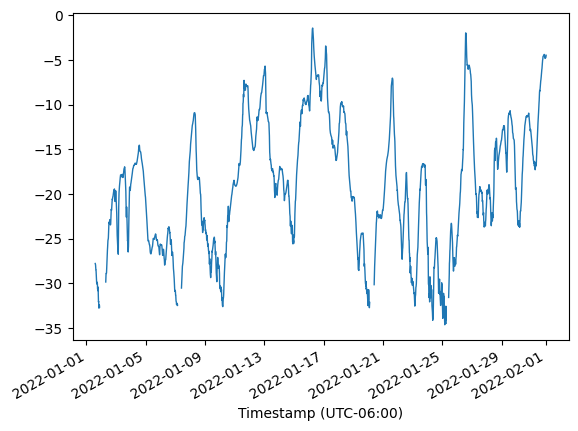

In [12]:
temp["Air temperature (Â°C)"].plot(lw=1)